# Лабораторна робота №4
## Бінарна класифікація табличних даних на прикладі Titanic

**Студент:** Михайло Вахнюк  
**Група:** МІТ-31
**Варіант:** 5  

**Тема:** побудова та оцінювання моделі бінарної класифікації для прогнозування виживання пасажирів Titanic.

**Мета:** навчитися виконувати повний цикл бінарної класифікації: дослідити дані, підготувати ознаки через `Pipeline`, побудувати базову та основну моделі, оцінити їх за метриками класифікації й дослідити вплив порога рішення.

**Набір даних:** Titanic із бібліотеки Seaborn.  
**Цільова змінна:** `survived`, де `0` — пасажир не вижив, `1` — пасажир вижив.

**Індивідуальне завдання (варіант 5):** порівняти `LogisticRegression` зі значеннями `class_weight=None` та `class_weight="balanced"`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

df = sns.load_dataset("titanic")

print("Розмір таблиці:", df.shape)
display(df.head())

Розмір таблиці: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Коментар:
- підключаємо бібліотеки для таблиць, графіків і моделей;
- SEED = 42 фіксує випадковість, щоб результати можна було відтворити;
- sns.load_dataset("titanic") завантажує навчальний набір Titanic;
- df.shape покаже розмір таблиці, а head() — перші 5 рядків.

## Підготовка та завантаження даних

Набір даних Titanic завантажено з бібліотеки Seaborn. Він містить інформацію про пасажирів корабля та ознаку `survived`, яка показує факт виживання. Для відтворюваності експерименту встановлено `SEED = 42`. Форма таблиці та перші рядки дають змогу переконатися, що дані успішно завантажено.


In [2]:
print("Перші 5 рядків:")
display(df.head())

print("Інформація про таблицю:")
df.info()

print("\nОпис усіх стовпців:")
display(df.describe(include="all"))

print("Кількість дублікатів:", df.duplicated().sum())

missing = pd.DataFrame({
    "Кількість пропусків": df.isna().sum(),
    "Частка пропусків, %": (df.isna().mean() * 100).round(2)
}).sort_values("Частка пропусків, %", ascending=False)

class_balance = pd.DataFrame({
    "Кількість": df["survived"].value_counts().sort_index(),
    "Частка, %": (df["survived"].value_counts(normalize=True).sort_index() * 100).round(2)
})
class_balance.index = ["Не вижив (0)", "Вижив (1)"]

print("\nПропуски:")
display(missing)

print("Баланс цільового класу:")
display(class_balance)

Перші 5 рядків:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Інформація про таблицю:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Опис усіх стовпців:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Кількість дублікатів: 107

Пропуски:


,Кількість пропусків,"Частка пропусків, %"
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


Баланс цільового класу:


,Кількість,"Частка, %"
Не вижив (0),549,61.62
Вижив (1),342,38.38


Коментар:
- info() показує типи стовпців і кількість непорожніх значень;
- describe(include="all") показує статистики числових та категоріальних ознак;
- перевіряємо дублікати;
- окремо рахуємо пропуски й баланс класів виживання;
- рядки з пропуском у age поки не видаляємо: їх коректно заповнить Pipeline пізніше, після поділу на train/test.

## Первинний аналіз даних

Було перевірено структуру набору, типи даних, описові статистики, пропуски та дублікати. Пропуски присутні в окремих ознаках, зокрема у віці пасажирів, тому їх не видаляємо вручну. Їх буде оброблено всередині `Pipeline` лише за даними навчальної вибірки, щоб уникнути витоку даних. Також визначено баланс класів `survived`, який важливо врахувати під час оцінювання класифікатора.

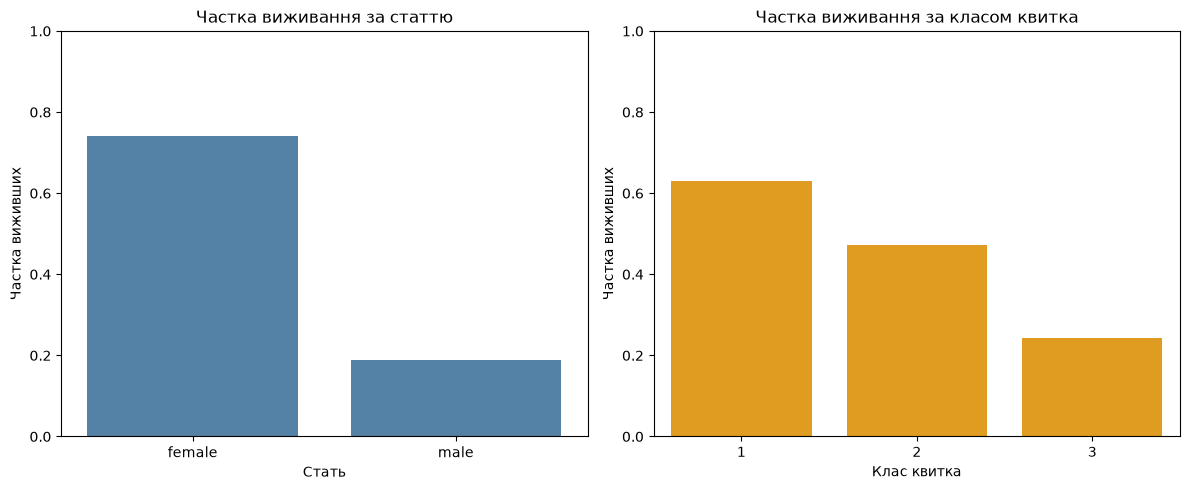

In [3]:
survival_by_sex = df.groupby("sex")["survived"].mean().reset_index()
survival_by_class = df.groupby("pclass")["survived"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=survival_by_sex,
    x="sex",
    y="survived",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Частка виживання за статтю")
axes[0].set_xlabel("Стать")
axes[0].set_ylabel("Частка виживших")
axes[0].set_ylim(0, 1)

sns.barplot(
    data=survival_by_class,
    x="pclass",
    y="survived",
    ax=axes[1],
    color="orange"
)
axes[1].set_title("Частка виживання за класом квитка")
axes[1].set_xlabel("Клас квитка")
axes[1].set_ylabel("Частка виживших")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

Коментар: groupby() об’єднує пасажирів за статтю або класом, а середнє survived показує частку виживших у кожній групі: оскільки survived містить лише 0 і 1, його середнє дорівнює відсотку виживання у десятковому форматі.

### Візуальний аналіз

Графіки показують, що частка виживання відрізняється залежно від статі та класу квитка. Отже, ознаки `sex` і `pclass` можуть бути корисними для прогнозування виживання. Це лише статистичні закономірності в наборі даних, а не доказ причинного зв’язку.

In [4]:
data = df.copy()

data["FamilySize"] = data["sibsp"] + data["parch"] + 1

numeric_features = ["age", "sibsp", "parch", "fare", "FamilySize"]
categorical_features = ["pclass", "sex", "embarked"]

X = data[numeric_features + categorical_features]
y = data["survived"]

print("Розмір матриці ознак X:", X.shape)
print("Розмір цілі y:", y.shape)
display(X.head())

Розмір матриці ознак X: (891, 8)
Розмір цілі y: (891,)


,age,sibsp,parch,fare,FamilySize,pclass,sex,embarked
0,22.0,1,0,7.2500,2,3,male,S
1,38.0,1,0,71.2833,2,1,female,C
2,26.0,0,0,7.9250,1,3,female,S
3,35.0,1,0,53.1000,2,1,female,S
4,35.0,0,0,8.0500,1,3,male,S


Коментар: створено нову ознаку FamilySize — розмір сім’ї на борту. До sibsp (брати/сестри та чоловік/дружина) і parch (батьки/діти) додається 1, бо сам пасажир теж є членом своєї групи. X містить лише ознаки для моделі, а y — ціль survived. Стовпець pclass обробляємо як категоріальний: значення 1, 2, 3 є кодами класу квитка, а не неперервним числом.

## Формування ознак і цілі

Створено додаткову ознаку `FamilySize`, що показує розмір сімейної групи пасажира на борту. Одиниця додається для врахування самого пасажира. Для моделі використано числові ознаки `age`, `sibsp`, `parch`, `fare`, `FamilySize` та категоріальні ознаки `pclass`, `sex`, `embarked`. Цільова змінна — `survived`. Стовпці, що дублюють ціль або інші ознаки, не використовуються.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)

print("\nЧастка виживших у всіх даних:", round(y.mean(), 3))
print("Частка виживших у train:", round(y_train.mean(), 3))
print("Частка виживших у test:", round(y_test.mean(), 3))

Розмір X_train: (712, 8)
Розмір X_test: (179, 8)

Частка виживших у всіх даних: 0.384
Частка виживших у train: 0.383
Частка виживших у test: 0.385


Коментар: 80% даних ідуть на навчання, 20% — на фінальну перевірку. stratify=y зберігає приблизно однакову частку виживших у початковому наборі, train і test. random_state=SEED робить поділ відтворюваним. Після цього тестові дані не використовуємо для навчання моделі, добору ознак чи вибору параметрів.

## Поділ даних

Дані поділено у співвідношенні 80/20 на навчальну та тестову вибірки. Використано `stratify=y`, тому баланс класів `survived` збережено в обох частинах. Навчальна вибірка застосовуватиметься для побудови моделей, а тестова — лише для незалежного фінального оцінювання.

In [6]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Клас, який завжди прогнозує базова модель:", baseline.classes_[baseline.class_prior_.argmax()])
print("Перші 10 прогнозів базової моделі:", baseline_pred[:10])

Клас, який завжди прогнозує базова модель: 0
Перші 10 прогнозів базової моделі: [0 0 0 0 0 0 0 0 0 0]


Коментар: DummyClassifier(strategy="most_frequent") не використовує закономірності в ознаках. Він завжди обирає клас, який найчастіше траплявся у навчальній вибірці. Це мінімальний орієнтир: основна модель має працювати краще, інакше її використання не має сенсу

## Базова модель

Побудовано `DummyClassifier` зі стратегією `most_frequent`. Ця модель завжди прогнозує найпоширеніший клас навчальної вибірки та не аналізує характеристики пасажирів. Вона використовується як базовий рівень для подальшого порівняння з логістичною регресією.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("prepare", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight=None
    ))
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepare', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

Коментар: числові пропуски заповнюються медіаною, після чого числові ознаки масштабуються через StandardScaler. Категоріальні пропуски заповнюються найчастішим значенням, а категорії перетворюються на числові колонки через OneHotEncoder. handle_unknown="ignore" не дає помилки, якщо у тестових даних зустрінеться категорія, якої не було в навчальних. Усі перетворення й модель об’єднані в Pipeline, тому навчаються лише на train — це захищає від витоку даних

## Підготовка ознак у Pipeline

Для числових ознак використано заповнення пропусків медіаною та стандартизацію. Для категоріальних ознак використано заповнення найчастішим значенням і one-hot кодування. `ColumnTransformer` застосовує різну підготовку до різних типів стовпців, а `Pipeline` поєднує підготовку з `LogisticRegression`. Такий підхід запобігає витоку даних із тестової вибірки.

In [8]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Перші 10 прогнозованих класів:", y_pred[:10])
print("Перші 10 імовірностей виживання:", np.round(y_proba[:10], 3))

Перші 10 прогнозованих класів: [0 0 0 0 1 0 1 0 0 0]
Перші 10 імовірностей виживання: [0.068 0.048 0.157 0.036 0.671 0.441 0.767 0.307 0.345 0.175]


Коментар: fit() навчає весь Pipeline лише на навчальних даних. predict() повертає прогнозований клас — 0 або 1. predict_proba()[:, 1] повертає ймовірність позитивного класу, тобто ймовірність виживання пасажира. За замовчуванням клас 1 присвоюється, якщо ця ймовірність не менша за 0,5.

## Навчання та прогнозування

Логістичну регресію навчено на навчальній вибірці. Для тестової вибірки отримано прогнозовані класи та ймовірності виживання. Імовірності будуть використані для ROC AUC, Average Precision і подальшого аналізу порога рішення.

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def classification_metrics(y_true, y_hat):
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0)
    }

results = pd.DataFrame(
    [
        classification_metrics(y_test, baseline_pred),
        classification_metrics(y_test, y_pred)
    ],
    index=["DummyClassifier", "LogisticRegression"]
)

results.loc["LogisticRegression", "roc_auc"] = roc_auc_score(y_test, y_proba)
results.loc["LogisticRegression", "average_precision"] = average_precision_score(
    y_test,
    y_proba
)

display(results.round(3))

,accuracy,precision,recall,f1,roc_auc,average_precision
DummyClassifier,0.615,0.000,0.000,0.000,NaN,NaN
LogisticRegression,0.804,0.793,0.667,0.724,0.843,0.786


Коментар: accuracy показує частку правильних відповідей загалом. precision показує, яка частка прогнозів «вижив» справді вижила. recall показує, скільки реальних випадків виживання знайшла модель. F1 балансує precision і recall. ROC AUC та Average Precision обчислюються за ймовірностями, бо оцінюють якість моделі за різних порогів, а не лише за порогу 0,5. zero_division=0 запобігає помилці для базової моделі, якщо вона взагалі не прогнозує виживання.

## Оцінювання якості моделі

Якість класифікації оцінено за метриками accuracy, precision, recall, F1, ROC AUC та Average Precision. Логістичну регресію порівняно з `DummyClassifier`. Основна модель є корисною, якщо її метрики кращі за базовий орієнтир, який не використовує ознаки пасажирів.

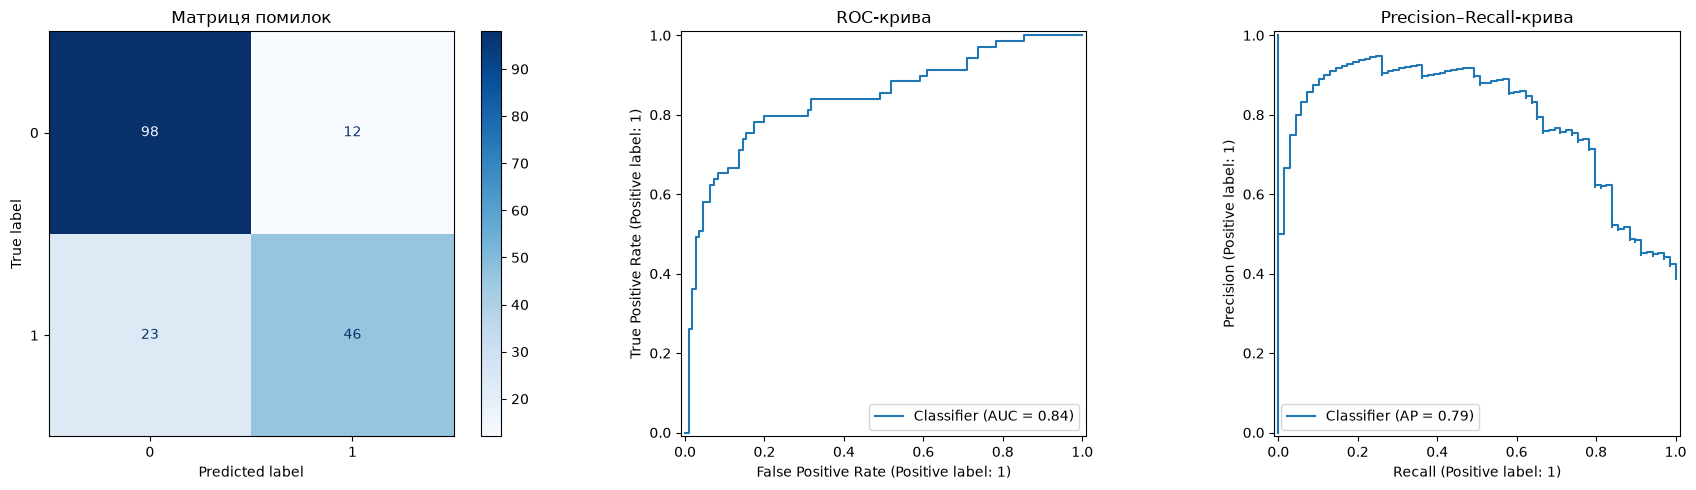

In [10]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Матриця помилок")

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=axes[1]
)
axes[1].set_title("ROC-крива")

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    ax=axes[2]
)
axes[2].set_title("Precision–Recall-крива")

plt.tight_layout()
plt.show()

Коментар: матриця помилок показує кількість правильних та неправильних прогнозів: TN, TP, FP, FN. ROC-крива оцінює здатність моделі відрізняти класи за різних порогів. Precision–Recall-крива показує компроміс між точністю позитивних прогнозів і повнотою знайдених випадків виживання.

### Графічне оцінювання

Матриця помилок дає змогу побачити кількість правильних і помилкових прогнозів. ROC-крива та Precision–Recall-крива побудовані за прогнозованими ймовірностями виживання. Вони показують, як змінюється якість класифікації при різних порогах рішення.

In [11]:
threshold_rows = []

for threshold in [0.30, 0.50, 0.70]:
    pred_t = (y_proba >= threshold).astype(int)

    row = classification_metrics(y_test, pred_t)
    row["threshold"] = threshold

    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")

display(threshold_results.round(3))

,accuracy,precision,recall,f1
threshold,,,,
0.3,0.771,0.671,0.797,0.728
0.5,0.804,0.793,0.667,0.724
0.7,0.788,0.897,0.507,0.648


Коментар: стандартний поріг 0,50 означає: модель прогнозує виживання, якщо ймовірність виживання не менша за 50%. При зменшенні порога до 0,30 модель частіше прогнозуватиме виживання: зазвичай recall зростає, але precision може зменшитися. При збільшенні порога до 0,70 ситуація зазвичай протилежна. Це навчальний аналіз на тестовій вибірці, а не вибір універсально оптимального порога для реального застосування.

## Аналіз порога рішення

Було порівняно пороги 0,30, 0,50 і 0,70. У сценарії, де пропустити пасажира, який вижив, є дорожчою помилкою, важливішим є `recall`. Тому доцільно розглядати нижчий поріг, наприклад 0,30, якщо він забезпечує вищий recall. Водночас зниження порога може збільшити кількість хибнопозитивних прогнозів і зменшити precision.

In [12]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test
error_analysis["predicted"] = y_pred
error_analysis["probability"] = y_proba

false_positive = error_analysis.query("actual == 0 and predicted == 1")
false_negative = error_analysis.query("actual == 1 and predicted == 0")

print("False Positive (FP) — модель сказала «вижив», але пасажир не вижив:")
display(
    false_positive
    .sort_values("probability", ascending=False)
    .head(5)
)

print("False Negative (FN) — модель сказала «не вижив», але пасажир вижив:")
display(
    false_negative
    .sort_values("probability", ascending=True)
    .head(5)
)

False Positive (FP) — модель сказала «вижив», але пасажир не вижив:


,age,sibsp,parch,fare,FamilySize,pclass,sex,embarked,actual,predicted,probability
297,2.0,1,2,151.5500,4,1,female,S,0,1,0.965727
199,24.0,0,0,13.0000,1,2,female,S,0,1,0.838099
501,21.0,0,0,7.7500,1,3,female,Q,0,1,0.772259
502,NaN,0,0,7.6292,1,3,female,Q,0,1,0.718875
593,NaN,0,2,7.7500,3,3,female,Q,0,1,0.683636


False Negative (FN) — модель сказала «не вижив», але пасажир вижив:


,age,sibsp,parch,fare,FamilySize,pclass,sex,embarked,actual,predicted,probability
570,62.0,0,0,10.5000,1,2,male,S,1,0,0.083417
444,NaN,0,0,8.1125,1,3,male,S,1,0,0.087915
804,27.0,0,0,6.9750,1,3,male,S,1,0,0.092276
146,27.0,0,0,7.7958,1,3,male,S,1,0,0.092468
271,25.0,0,0,0.0000,1,3,male,S,1,0,0.097051


Коментар: FP — хибнопозитивні помилки: модель прогнозує виживання, хоча пасажир не вижив. FN — хибнонегативні помилки: модель прогнозує загибель, хоча пасажир вижив. Сортування показує п’ять найбільш упевнених помилок: для FP — найбільші ймовірності виживання, для FN — найменші.

## Аналіз окремих помилок

Проаналізовано щонайменше п’ять хибнопозитивних (`FP`) і п’ять хибнонегативних (`FN`) прогнозів. Можливими причинами помилок є обмежений набір ознак та припущення логістичної регресії про лінійний зв’язок між перетвореними ознаками і логарифмом шансів виживання. Поліпшити експеримент можна додаванням нових змістовних ознак або порівнянням з іншими алгоритмами класифікації, наприклад деревом рішень.

**Індивідуальне завдання**

In [13]:
model_balanced = Pipeline([
    ("prepare", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight="balanced"
    ))
])

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
y_proba_balanced = model_balanced.predict_proba(X_test)[:, 1]

variant_results = pd.DataFrame(
    [
        classification_metrics(y_test, y_pred),
        classification_metrics(y_test, y_pred_balanced)
    ],
    index=[
        "LogisticRegression (class_weight=None)",
        "LogisticRegression (class_weight=balanced)"
    ]
)

variant_results["roc_auc"] = [
    roc_auc_score(y_test, y_proba),
    roc_auc_score(y_test, y_proba_balanced)
]

variant_results["average_precision"] = [
    average_precision_score(y_test, y_proba),
    average_precision_score(y_test, y_proba_balanced)
]

display(variant_results.round(3))

,accuracy,precision,recall,f1,roc_auc,average_precision
LogisticRegression (class_weight=None),0.804,0.793,0.667,0.724,0.843,0.786
LogisticRegression (class_weight=balanced),0.810,0.740,0.783,0.761,0.846,0.788


Коментар: звичайна модель вважає помилки обох класів однаково важливими. У моделі з class_weight="balanced" більша вага автоматично надається менш представленому класу — у цьому наборі це клас виживших. Така модель часто підвищує recall для класу 1, але може зменшувати precision або accuracy. Порівнювати потрібно за всіма метриками, а не лише за однією.

## Індивідуальне завдання — варіант 5

Було порівняно дві моделі `LogisticRegression`: зі стандартним значенням `class_weight=None` і зі значенням `class_weight="balanced"`. Балансування ваг класів надає більшої важливості менш представленому класу виживших пасажирів. За таблицею метрик можна визначити, чи зросла повнота (`recall`) виявлення виживших і яким став компроміс із precision, accuracy та F1.

## Висновок

У роботі побудовано модель бінарної класифікації для прогнозування виживання пасажирів Titanic. Дані було поділено на навчальну і тестову вибірки зі стратифікацією, а пропуски та категоріальні ознаки оброблено всередині `Pipeline`. Це дало змогу уникнути витоку даних із тестової вибірки.

Якість `LogisticRegression` оцінено за метриками accuracy, precision, recall, F1, ROC AUC та Average Precision і порівняно з базовою моделлю `DummyClassifier`. За отриманою таблицею метрик логістична регресія використовує характеристики пасажирів і є інформативнішою за базову модель, яка завжди прогнозує найпоширеніший клас.

Матриця помилок показала кількість правильних прогнозів і помилок FP та FN. Аналіз порогів 0,30, 0,50 і 0,70 продемонстрував компроміс між precision та recall: зменшення порога зазвичай допомагає знайти більше реальних випадків виживання, але може збільшувати кількість хибнопозитивних прогнозів.

У варіанті 5 порівняно звичайну логістичну регресію (`class_weight=None`) і модель з балансуванням класів (`class_weight="balanced"`). Балансування може підвищувати recall класу виживших, але його вплив потрібно оцінювати разом з precision, accuracy та F1 за отриманою таблицею.

Обмеженнями експерименту є невеликий набір даних, неповнота окремих ознак і припущення логістичної регресії. Поліпшити експеримент можна додаванням змістовних ознак, підбором параметрів лише на навчальних даних і порівнянням з іншими класифікаторами.

## Джерела

- Titanic dataset (Seaborn): https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv
- Документація scikit-learn: https://scikit-learn.org/stable/
- Репозиторій роботи: https://github.com/vamyvkhailo/Data_Science_Labs